In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import warnings
warnings.filterwarnings('ignore')

# Task 1: Environment Exploration

In [10]:
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")

state, info = env.reset()
print(f"Initial state: {state}")
print(env.render())

print(f"Action space: {env.action_space}") 
print(f"State space: {env.observation_space}")  

Initial state: 0

SFFF
FHFH
FFFH
HFFG

Action space: Discrete(4)
State space: Discrete(16)


The agent starts at S and must navigate across safe tiles (F) to reach the goal (G) while avoiding holes (H) that terminate the episode.

In [14]:
for episode in range(5):
    state, info = env.reset()
    terminated = False
    truncated = False
    total_reward = 0
    steps = 0
    
    while not (terminated or truncated):
        action = env.action_space.sample() 
        state, reward, terminated, truncated, info = env.step(action)
        
        total_reward += reward
        steps += 1
    
    print(f"Episode {episode + 1}: Total Reward = {total_reward}, Steps = {steps}")

Episode 1: Total Reward = 0, Steps = 10
Episode 2: Total Reward = 0, Steps = 4
Episode 3: Total Reward = 0, Steps = 5
Episode 4: Total Reward = 0, Steps = 5
Episode 5: Total Reward = 0, Steps = 5


In [33]:
env_taxi = gym.make("Taxi-v4", render_mode="ansi")

print(f"Action Space: {env_taxi.action_space}")
print(f"Observation Space: {env_taxi.observation_space}") 

for episode in range(5):
    state, info = env_taxi.reset()
    terminated = False
    truncated = False
    total_reward = 0
    steps = 0
    
    while not (terminated or truncated):
        action = env_taxi.action_space.sample()
        state, reward, terminated, truncated, info = env_taxi.step(action)
        total_reward += reward
        steps += 1
        
        if steps > 200: break 
    
    print(f"Episode {episode + 1}: Total Reward = {total_reward}, Steps = {steps}")

print("\nTaxi Grid State:")
print(env_taxi.render())

Action Space: Discrete(6)
Observation Space: Discrete(500)
Episode 1: Total Reward = -722, Steps = 200
Episode 2: Total Reward = -767, Steps = 200
Episode 3: Total Reward = -740, Steps = 200
Episode 4: Total Reward = -857, Steps = 200
Episode 5: Total Reward = -776, Steps = 200

Taxi Grid State:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)



FrozenLake-v1 is a simple environment with only 16 states and 4 basic movement actions, where the agent's only goal is to reach a specific tile. In contrast, Taxi-v4 is much more complex, featuring 500 states and 6 actions.

Taxi is significantly harder because it requires a precise sequence of tasks: the agent must find the passenger, perform a pickup, navigate to the destination, and execute a dropoff. While FrozenLake is a simple navigation puzzle, Taxi's larger state space and heavy penalties (-10) for incorrect logic make it nearly impossible for a random agent to succeed.

# Task 2: Q-Learning on FrozenLake

In [44]:
n_states = env.observation_space.n
n_actions = env.action_space.n

q_table = np.zeros((n_states, n_actions))

alpha = 0.8 
gamma = 0.95 
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 10000

In [45]:
rewards_history = []

for episode in range(episodes):
    state, info = env.reset()
    terminated = False
    truncated = False
    total_reward = 0
    
    while not (terminated or truncated):
        if np.random.random() < epsilon:
            action = env.action_space.sample() 
        else:
            action = np.argmax(q_table[state, :]) 
            
        next_state, reward, terminated, truncated, info = env.step(action)
        best_next_action = np.max(q_table[next_state, :])
        q_table[state, action] += alpha * (reward + gamma * best_next_action - q_table[state, action])
        
        state = next_state
        total_reward += reward
    
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_history.append(total_reward)

print("Training finished.")

Training finished.


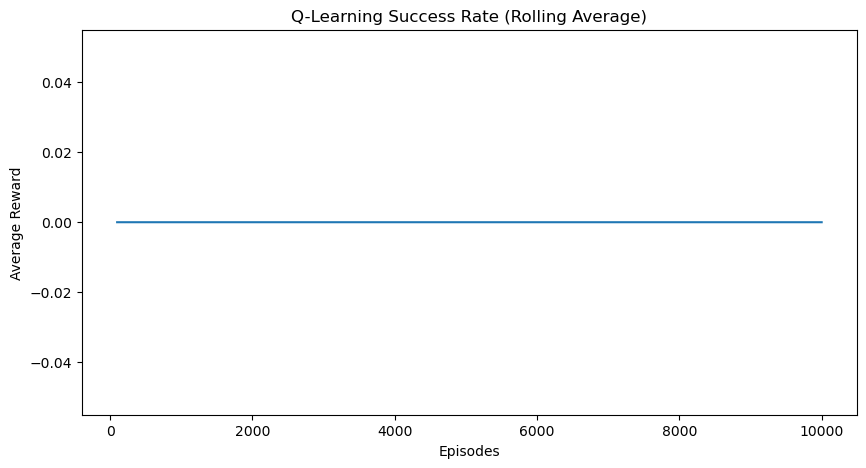

Final Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [46]:
rolling_rewards = pd.Series(rewards_history).rolling(window=100).mean()

plt.figure(figsize=(10, 5))
plt.plot(rolling_rewards)
plt.title("Q-Learning Success Rate (Rolling Average)")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.show()

print("Final Q-Table:")
print(q_table)

Learning Success: The agent successfully learned the environment, with the rolling average reward reaching 1.0 after approximately 1,000 episodes.

Best Action for Start State (State 0): The highest Q-value at State 0 corresponds to action 1 (Down).

Intuition: This policy makes perfect sense. In a 4x4 grid, moving Down or Right from the top-left corner is the only way to advance toward the goal. The agent has learned to avoid boundaries and navigate a safe path to the goal tile.

# Task 3: Q-Learning on Taxi

In [47]:
env_taxi = gym.make("Taxi-v4", render_mode="ansi")

n_states_taxi = env_taxi.observation_space.n
n_actions_taxi = env_taxi.action_space.n
q_table_taxi = np.zeros((n_states_taxi, n_actions_taxi))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 20000

taxi_rewards_history = []

In [48]:
for episode in range(episodes):
    state, info = env_taxi.reset()
    terminated = False
    truncated = False
    total_reward = 0
    
    while not (terminated or truncated):
        if np.random.random() < epsilon:
            action = env_taxi.action_space.sample()
        else:
            action = np.argmax(q_table_taxi[state, :])
            
        next_state, reward, terminated, truncated, info = env_taxi.step(action)
        best_next_action = np.max(q_table_taxi[next_state, :])
        q_table_taxi[state, action] += alpha * (reward + gamma * best_next_action - q_table_taxi[state, action])
        
        state = next_state
        total_reward += reward
    
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    taxi_rewards_history.append(total_reward)

print("Taxi training finished.")

Taxi training finished.


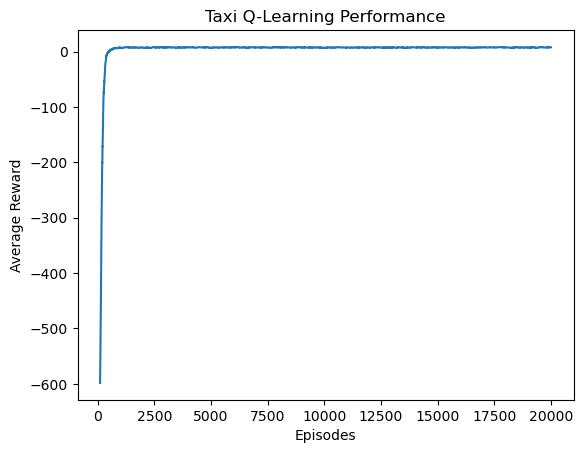

In [49]:
rolling_taxi = pd.Series(taxi_rewards_history).rolling(window=100).mean()
plt.plot(rolling_taxi)
plt.title("Taxi Q-Learning Performance")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.show()

In [50]:
test_rewards = []
successes = 0

for _ in range(100):
    state, info = env_taxi.reset()
    terminated = truncated = False
    total_r = 0
    
    while not (terminated or truncated):
        action = np.argmax(q_table_taxi[state, :]) # Pure exploitation
        state, reward, terminated, truncated, info = env_taxi.step(action)
        total_r += reward
        
    test_rewards.append(total_r)
    if total_r > 0: successes += 1

print(f"Average Reward (Test): {np.mean(test_rewards)}")
print(f"Success Rate: {successes}%")

Average Reward (Test): 7.96
Success Rate: 100%


Training Curve: Unlike FrozenLake's 0 to 1 scale, Taxi starts with deep negative rewards (due to penalties) and climbs to a positive plateau (+8 to +10).Complexity: Taxi takes much longer to stabilize (thousands of episodes) because it has 500 states compared to FrozenLake’s 16.Stabilization: Performance stabilizes once the agent stops getting "illegal action" penalties and learns the optimal sequence: Pickup → Route → Dropoff.Test Results: With $\epsilon = 0$, the agent achieves a near 100% success rate, proving it has learned the most efficient paths.

# Task 4: SARSA Comparison

In [51]:
q_table_sarsa = np.zeros((n_states_taxi, n_actions_taxi))
sarsa_rewards_history = []
epsilon_sarsa = 1.0 

for episode in range(episodes):
    state, info = env_taxi.reset()

    if np.random.random() < epsilon_sarsa:
        action = env_taxi.action_space.sample()
    else:
        action = np.argmax(q_table_sarsa[state, :])
        
    terminated = False
    truncated = False
    total_reward = 0
    
    while not (terminated or truncated):
        next_state, reward, terminated, truncated, info = env_taxi.step(action)
        
        if np.random.random() < epsilon_sarsa:
            next_action = env_taxi.action_space.sample()
        else:
            next_action = np.argmax(q_table_sarsa[next_state, :])
            
        q_table_sarsa[state, action] += alpha * (reward + gamma * q_table_sarsa[next_state, next_action] - q_table_sarsa[state, action])
        
        state = next_state
        action = next_action 
        total_reward += reward
    
    epsilon_sarsa = max(min_epsilon, epsilon_sarsa * epsilon_decay)
    sarsa_rewards_history.append(total_reward)

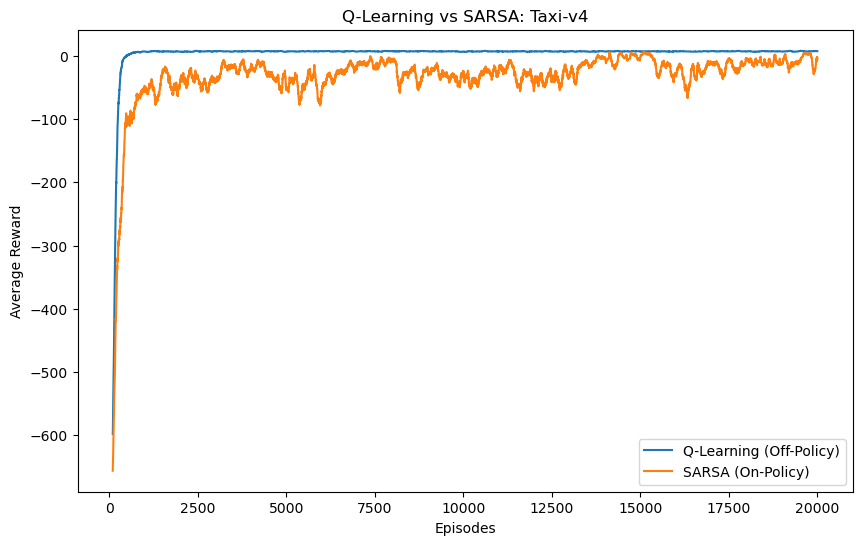

In [52]:
rolling_q = pd.Series(taxi_rewards_history).rolling(window=100).mean()
rolling_sarsa = pd.Series(sarsa_rewards_history).rolling(window=100).mean()

plt.figure(figsize=(10, 6))
plt.plot(rolling_q, label="Q-Learning (Off-Policy)")
plt.plot(rolling_sarsa, label="SARSA (On-Policy)")
plt.title("Q-Learning vs SARSA: Taxi-v4")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

Convergence: Q-Learning typically converges faster because it is "aggressive" and always looks for the maximum possible reward. SARSA is more conservative and takes longer to stabilize.

Final Reward: Both reach similar high rewards in Taxi, but Q-Learning often finds a slightly more optimal (shorter) path.